# Bank Telemarketing Case Study
---------------------------------------------

Description : You are provided with Bank's Existing Customer Data.

A Telemarketing Campaign was Done by the Bank Offering Variuos Banking Products e.g. Term Deposits / FD

As an Analyst you are required to perform EDA On Telemarketing Data and Find various Insights & Facts .

the Facts Collected will be used by Authority/ Management to increase Profits
and Reduce Cost of Future Telemarking Campagins.

Dataset URL :

https://drive.google.com/file/d/1rsYRSm5SD0w4-Cb1H0XRwYvdzh9iUaHX/view?usp=sharing

# Import Libraries
---------------------

In [ ]:
# Processing Libraries
import numpy as np
import pandas as pd


# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Load Data
----------------

In [ ]:
inp0 = pd.read_csv('v1.csv' , skiprows=2)

In [ ]:
# Preview your Data
inp0.head(3)

,customerid,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,1,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,2,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no
2,3,33.0,120000,2,married,"entrepreneur,secondary",yes,no,yes,yes,unknown,5,"may, 2017",76 sec,1,-1,0,unknown,no


# Data Inspection
----------------------------------
<pre>
1- Find the Count of ROWS
2- Find Column DataTypes
3- Missing Value Inspection

In [ ]:
print('Total Records COUNT ' , len( inp0 ))

Total Records COUNT  45211


In [ ]:
# DataType inspection
print( inp0.dtypes)

customerid      int64
age           float64
salary          int64
balance         int64
marital        object
jobedu         object
targeted       object
default        object
housing        object
loan           object
contact        object
day             int64
month          object
duration       object
campaign        int64
pdays           int64
previous        int64
poutcome       object
response       object
dtype: object


In [ ]:
# Missing Value  Inspection
inp0.isna().sum().sort_values(ascending=False)

,0
month,50
response,30
age,20
salary,0
customerid,0
balance,0
marital,0
default,0
housing,0
jobedu,0


what is the average age of customer in our Bank ?


In [ ]:
inp0.age.mean()

np.float64(40.93565090394105)

In [ ]:
inp0.customerid.head(3)

,customerid
0,1
1,2
2,3


Dropping CustomerID Field

In [ ]:
inp0.drop( 'customerid',axis=1,inplace=True)

In [ ]:
inp0.head(2)

,age,salary,balance,marital,jobedu,targeted,default,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,response
0,58.0,100000,2143,married,"management,tertiary",yes,no,yes,no,unknown,5,"may, 2017",261 sec,1,-1,0,unknown,no
1,44.0,60000,29,single,"technician,secondary",yes,no,yes,no,unknown,5,"may, 2017",151 sec,1,-1,0,unknown,no


Populating New Columns to Optimize Analysis

In [ ]:
inp0.jobedu.head()

,jobedu
0,"management,tertiary"
1,"technician,secondary"
2,"entrepreneur,secondary"
3,"blue-collar,unknown"
4,"unknown,unknown"


In [ ]:
'management,tertiary'.split(',')

['management', 'tertiary']

In [ ]:
'management,tertiary'.split(',')[0]

'management'

In [ ]:
'management,tertiary'.split(',')[1]

'tertiary'

In [ ]:
inp0['job'] = inp0.jobedu.apply(   lambda line : line.split(',')[0])

In [ ]:
inp0.job.head()

,job
0,management
1,technician
2,entrepreneur
3,blue-collar
4,unknown


In [ ]:
inp0['edu'] = inp0.jobedu.apply(   lambda line : line.split(',')[1])

In [ ]:
inp0[['job','edu']].head()

,job,edu
0,management,tertiary
1,technician,secondary
2,entrepreneur,secondary
3,blue-collar,unknown
4,unknown,unknown


# Quick Investigation
----------------------------

- How Many Job Types we Have in our Data .
- What is the Customer Distribution by their Education in Percentage!

In [ ]:
# -Count of unique jobs
inp0.job.nunique()

12

In [ ]:
print( inp0.job.unique())

['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']


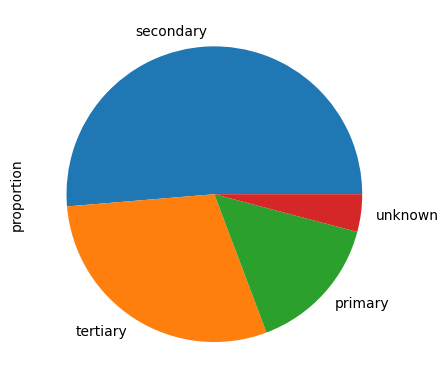

In [ ]:
# - Customer Distribution by their Education
inp0.edu.value_counts(normalize=True).plot(kind='pie');

# Missing Value Identification & Treatment
---------------------------------------------

# Target : AGE (Column)
------------------------------------------------

- How Many Missing Values are their in Age Column !
- What is the %age Occupancy of missing values in age column.

In [ ]:
inp0.age.isna().sum()

np.int64(20)

In [ ]:
(20/45211)*100

0.0442370219636814

In [ ]:
(inp0.age.isna().sum()/ len(inp0))*100

np.float64(0.0442370219636814)

# Observation
-------------------------
0.04% is the missing value occupancy in Age Column

- Do  you Suggest to Delete Rows Containing NaN in Age ?
- Do  you Suggest to Impute Nulls in Age Column ?

In [ ]:
inp1 = inp0[  ~ inp0.age.isnull() ] # fetched all records where age is not null !

In [ ]:
inp1.age.isna().sum()

np.int64(0)

# Target : Month (Column)
------------------------------------------------

- How Many Missing Values are their in Month Column !
- What is the %age Occupancy of missing values in Month column.

In [ ]:
inp1.month.isna().sum()

np.int64(50)

In [ ]:
(inp1.month.isna().sum()/len(inp1))*100

np.float64(0.11064149941360005)

# Observation
-------------------------
0.11% is the missing value occupancy in Month Column

- Do  you Suggest to Delete Rows Containing NaN in Month ?
- Do  you Suggest to Impute Nulls in Month Column ?

which impute value do you suggest ! mean / median or mode ?

In [ ]:
inp1.month.head()

,month
0,"may, 2017"
1,"may, 2017"
2,"may, 2017"
3,"may, 2017"
4,"may, 2017"


Find Mode Value for month Column!

In [ ]:
inp1.month.mode()

,month
0,"may, 2017"


In [ ]:
inp1.month.mode()[0]

'may, 2017'

In [ ]:
inp1.month.fillna( inp1.month.mode()[0] , inplace=True)

In [ ]:
inp1.month.isna().sum()

np.int64(0)

# Anomalies in Data/Field
--------------

In [ ]:
inp1.pdays.sample(5)

,pdays
10112,-1
24461,131
30136,-1
27365,113
19162,-1


In [ ]:
# -1 in this data represents absence of information

In [ ]:
inp1.pdays.describe()

,pdays
count,45191.000000
mean,40.181253
std,100.074099
min,-1.000000
25%,-1.000000
50%,-1.000000
75%,-1.000000
max,871.000000


Suggested Solution : replace -1 in pDays Field with NaN

In [ ]:
# Fixing /replacing -1 with NaN
inp1.loc[ inp1.pdays < 0 , 'pdays'] = np.nan

In [ ]:
inp1.pdays.describe()

,pdays
count,8252.000000
mean,224.523752
std,115.202715
min,1.000000
25%,133.000000
50%,194.500000
75%,327.000000
max,871.000000


#  Outlier Detection
---------------------------------

In [ ]:
inp1.age.describe()

,age
count,45191.000000
mean,40.935651
std,10.619198
min,18.000000
25%,33.000000
50%,39.000000
75%,48.000000
max,95.000000


# Use WHISKER PLOT TO VISUALIZE POTENTIAL OUTLIER
---------------------

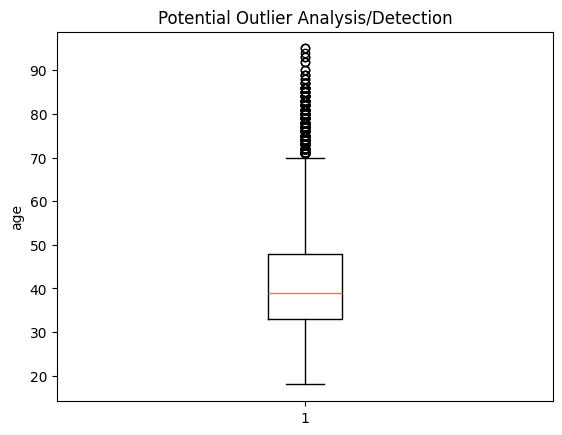

In [ ]:
plt.boxplot(inp1.age)
plt.title('Potential Outlier Analysis/Detection')
plt.ylabel('age')
plt.show()

# Data Analysis
------------------

## Univariate Analysis
----------------------------------
Analysis using Single Variable/Field/Column.

Let us Analyse Customer Distribution By Their Age

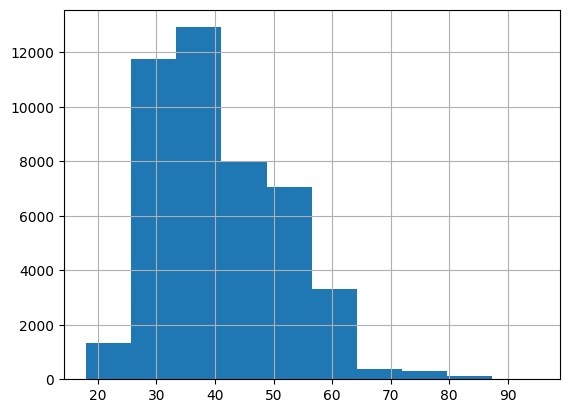

In [ ]:
inp1.age.hist();

Quick Question -
How many customers are there between the age of 30 and 50 ?


In [ ]:
inp1[inp1.age>70].shape[0]

487

In [ ]:
inp1[ (inp1.age.between(30,50))].shape[0]

30671

# Can You Try Finding the Customer Distribution by their Marital Status
---------------------

In [ ]:
inp1.marital.head()

,marital
0,married
1,single
2,married
3,married
4,single


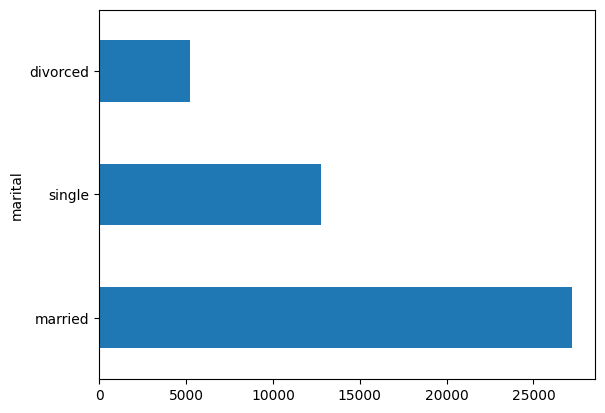

In [ ]:
inp1.marital.value_counts().plot(kind='barh');

# How Does the Customer Distribution Looks like by the Job they are Doing

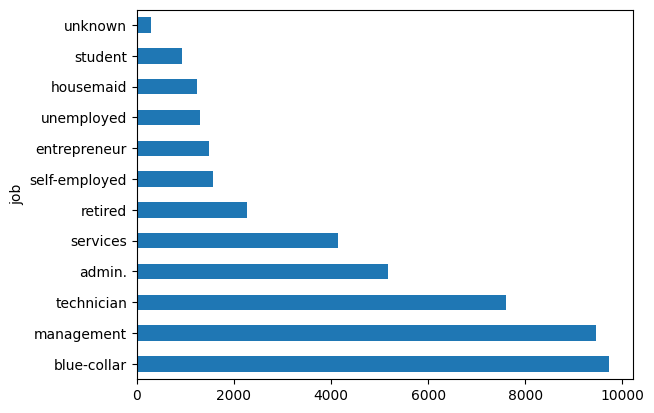

In [ ]:
inp1.job.value_counts().plot(kind='barh');

# BiVariate Analysis
---------------------------
Bivariate analysis means analysis using 2 fields/columns

# Balance vs Salary

In [ ]:
inp1[['balance','salary']].head()

,balance,salary
0,2143,100000
1,29,60000
2,2,120000
3,1506,20000
4,1,0


# Scatter Plot - right choice to do the bivariate anlysis
-------------------------------
scatter is used to study Data Distribution.

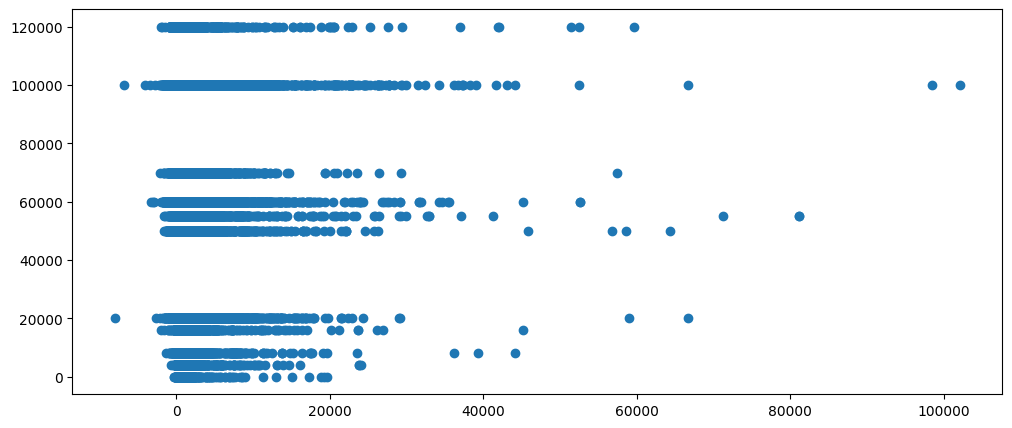

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter( inp1.balance,inp1.salary) #     X Axis , Y Axis
plt.show()

# Can U Try    Age vs Salary
---------------------------------

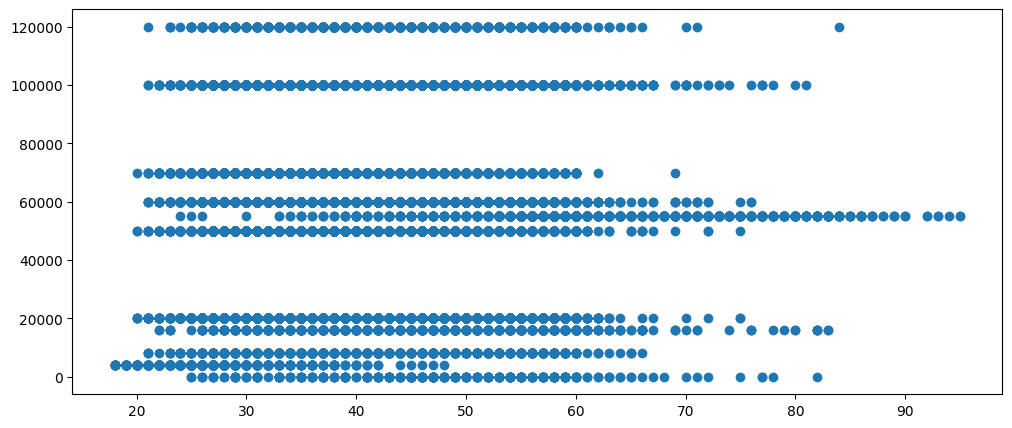

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter( inp1.age,inp1.salary) #     X Axis , Y Axis
plt.show()

# Age vs Balance
---------------------

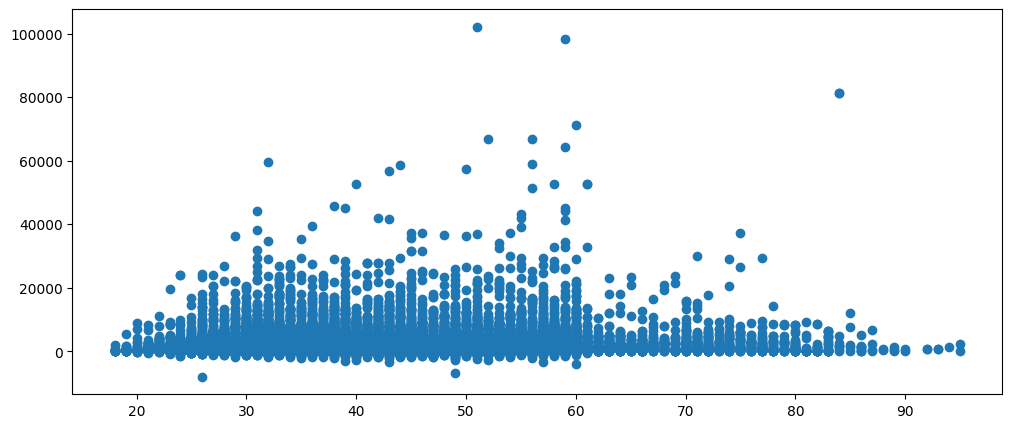

In [ ]:
plt.figure(figsize=(12,5))
plt.scatter( inp1.age,inp1.balance) #     X Axis , Y Axis
plt.show()

# Big Picture
----------------------------

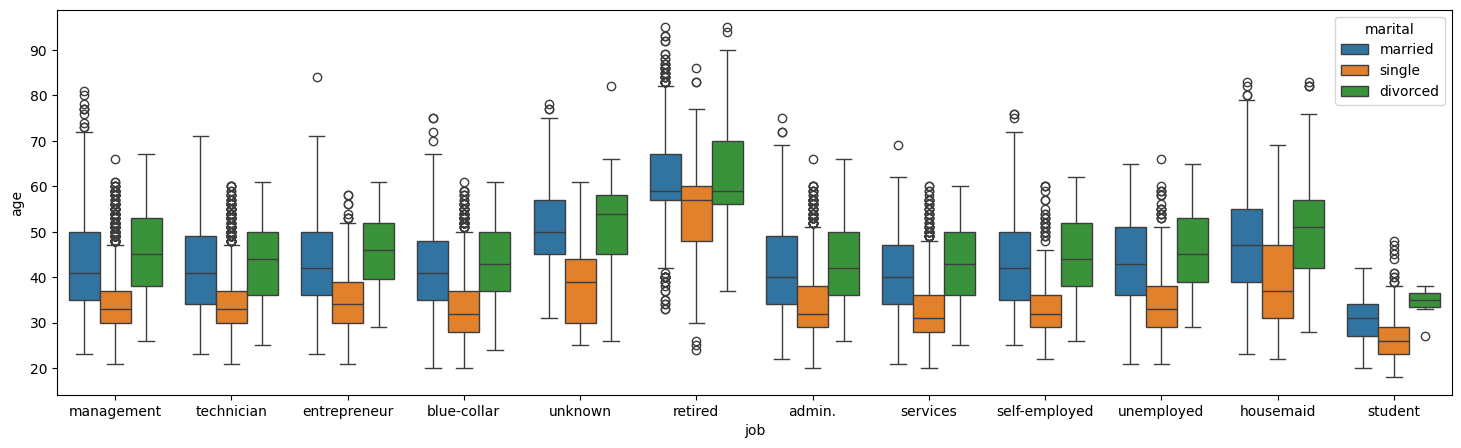

In [ ]:
plt.figure( figsize=(18,5))

sns.boxplot(x='job',y='age', hue='marital', data=inp1);

# Data Standardization
-----------------------

In [ ]:
inp1.duration.unique()

array(['261 sec', '151 sec', '76 sec', ..., '20.7666666666667 min',
       '25.9333333333333 min', '16.2833333333333 min'], dtype=object)

In [ ]:
inp1.duration =inp1.duration.apply( lambda x : float(x.split()[0])/60  if 'sec' in x else float(x.split()[0]))

In [ ]:
inp1.duration.unique()

array([ 4.35      ,  2.51666667,  1.26666667, ..., 20.76666667,
       25.93333333, 16.28333333])

In [ ]:
# Vipul Kumar Tiwari : if sec is found in data then take its value convert into min, if min then take min value.

In [ ]:
inp0.duration.unique()

array(['261 sec', '151 sec', '76 sec', ..., '20.7666666666667 min',
       '25.9333333333333 min', '16.2833333333333 min'], dtype=object)

In [ ]:
inp0.duration.apply(lambda x : x.split()[-1]).unique()

array(['sec', 'min'], dtype=object)

# MultiVariate Analysis
--------------------------------
Analysis using Multiple Variables/Fields

 # Correlation Matrix
 -------------

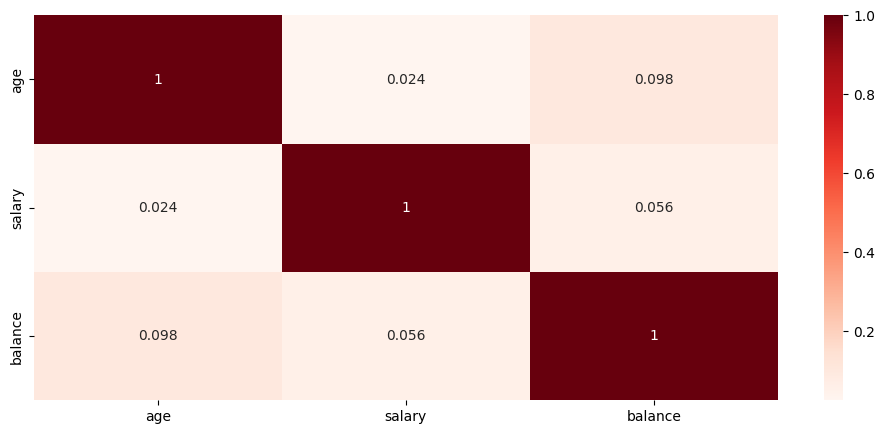

In [ ]:
plt.figure( figsize=(12,5))
sns.heatmap( inp1[['age','salary','balance']].corr() , annot=True,cmap='Reds')
plt.show()

# END